In [ ]:
install.packages(c("sqldf", "dplyr"))

In [ ]:
Sys.getenv("CONDA_DEFAULT_ENV")

In [ ]:
library(readxl)
library(sqldf)
library(dplyr)

Load the dataset

In [8]:
retail_sales <- as.data.frame(read_excel("datasets.xlsx", sheet = "retail_sales"))

In [9]:
colnames(retail_sales)

[1] "product_id"   "store_region" "season"       "units_sold"   "unit_price"  
[6] "discount"     "ad_spend"     "revenue"

# Question 1

## 1. SQL Query to identify top 5 selling products by total units_sold for each store_region and season.

In [12]:
sql_query <- "
SELECT store_region, season, product_id, total_units
FROM (
  SELECT store_region, season, product_id, SUM(units_sold) as total_units,
         ROW_NUMBER() OVER(PARTITION BY store_region, season ORDER BY SUM(units_sold) DESC) as rank
  FROM retail_sales
  GROUP BY store_region, season, product_id
)
WHERE rank <= 5
"

top_products <- sqldf(sql_query)

# Display the first few rows of the SQL result
print("Top Products by Region and Season:")
print(head(top_products, 10))

[1] "Top Products by Region and Season:"
   store_region season product_id total_units
1          East Autumn       P001         443
2          East Autumn       P026         158
3          East Autumn       P010         144
4          East Autumn       P027         137
5          East Autumn       P014         128
6          East Spring       P026         221
7          East Spring       P006         186
8          East Spring       P016         179
9          East Spring       P018         177
10         East Spring       P029         166


## 2. Load the result into R and compute median revenue and median discount for these products, grouped by season

In [15]:
# Create 'top_products_data' by joining the SQL result with the original dataset
top_products_data <- inner_join(retail_sales, top_products, 
                                by = c("store_region", "season", "product_id"))

# Clean the data: Force revenue and discount to be numbers
top_products_data <- top_products_data %>%
  mutate(
    revenue = as.numeric(revenue),
    discount = as.numeric(discount)
  )

# Calculate the medians
medians_summary <- top_products_data %>%
  group_by(season) %>%
  summarize(
    median_revenue = median(revenue, na.rm = TRUE),
    median_discount = median(discount, na.rm = TRUE)
  )

print("Median Revenue and Discount by Season:")
print(medians_summary)

[1] "Median Revenue and Discount by Season:"
# A tibble: 4 × 3
  season median_revenue median_discount
  <chr>           <dbl>           <dbl>
1 Autumn         64363.            16  
2 Spring         67535.            13  
3 Summer         62056.            13  
4 Winter         63036.            15.5


# QUESTION 2: DIAGNOSTICS

In [ ]:
library(car)
library(dplyr)

# 1. Calculate the profit margin
retail_sales <- retail_sales %>%
  mutate(
    revenue = as.numeric(revenue),
    ad_spend = as.numeric(ad_spend),
    profit_margin = revenue - ad_spend
  )

# 2. Shapiro-Wilk Normality Test per season
print("--- Shapiro-Wilk Test Results ---")
tapply(retail_sales$profit_margin, retail_sales$season, shapiro.test)

# 3. Levene's Test for Equality of Variances
print("--- Levene's Test Results ---")
leveneTest(profit_margin ~ as.factor(season), data = retail_sales)

Loading required package: carData


Attaching package: 'car'


The following object is masked from 'package:dplyr':

    recode




[1] "--- Shapiro-Wilk Test Results ---"


$Autumn

	Shapiro-Wilk normality test

data:  X[[i]]
W = 0.84382, p-value = 5.359e-06


$Spring

	Shapiro-Wilk normality test

data:  X[[i]]
W = 0.94245, p-value = 0.03483


$Summer

	Shapiro-Wilk normality test

data:  X[[i]]
W = 0.94012, p-value = 0.02388


$Winter

	Shapiro-Wilk normality test

data:  X[[i]]
W = 0.93361, p-value = 0.002835



[1] "--- Levene's Test Results ---"


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,3,1.105083,0.3482165
,196,NA,NA


In [17]:
# Kruskal-Wallis rank sum test
print("--- Kruskal-Wallis Test Results ---")
kruskal.test(profit_margin ~ as.factor(season), data = retail_sales)

[1] "--- Kruskal-Wallis Test Results ---"



	Kruskal-Wallis rank sum test

data:  profit_margin by as.factor(season)
Kruskal-Wallis chi-squared = 0.80618, df = 3, p-value = 0.848


# Question 3

[1] "--- Simple Regression Summary ---"



Call:
lm(formula = profit_margin ~ units_sold, data = retail_sales)

Residuals:
   Min     1Q Median     3Q    Max 
-70034 -26854   -572  20382  92842 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -19880.33    7983.51  -2.490   0.0136 *  
units_sold     532.23      57.17   9.309   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 32600 on 198 degrees of freedom
Multiple R-squared:  0.3044,	Adjusted R-squared:  0.3009 
F-statistic: 86.66 on 1 and 198 DF,  p-value: < 2.2e-16


[1] "--- Multiple Regression Summary ---"



Call:
lm(formula = profit_margin ~ units_sold + discount + ad_spend, 
    data = retail_sales)

Residuals:
   Min     1Q Median     3Q    Max 
-66509 -23648   -578  20601  78611 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  -446.7136 10978.5986  -0.041    0.968    
units_sold    499.1958    54.3633   9.183  < 2e-16 ***
discount    -1283.4075   249.3147  -5.148 6.39e-07 ***
ad_spend        0.2720     0.4844   0.562    0.575    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 30710 on 196 degrees of freedom
Multiple R-squared:  0.3889,	Adjusted R-squared:  0.3796 
F-statistic: 41.58 on 3 and 196 DF,  p-value: < 2.2e-16


[1] "--- Variance Inflation Factor (VIF) ---"


units_sold   discount   ad_spend 
  1.018697   1.017227   1.004288

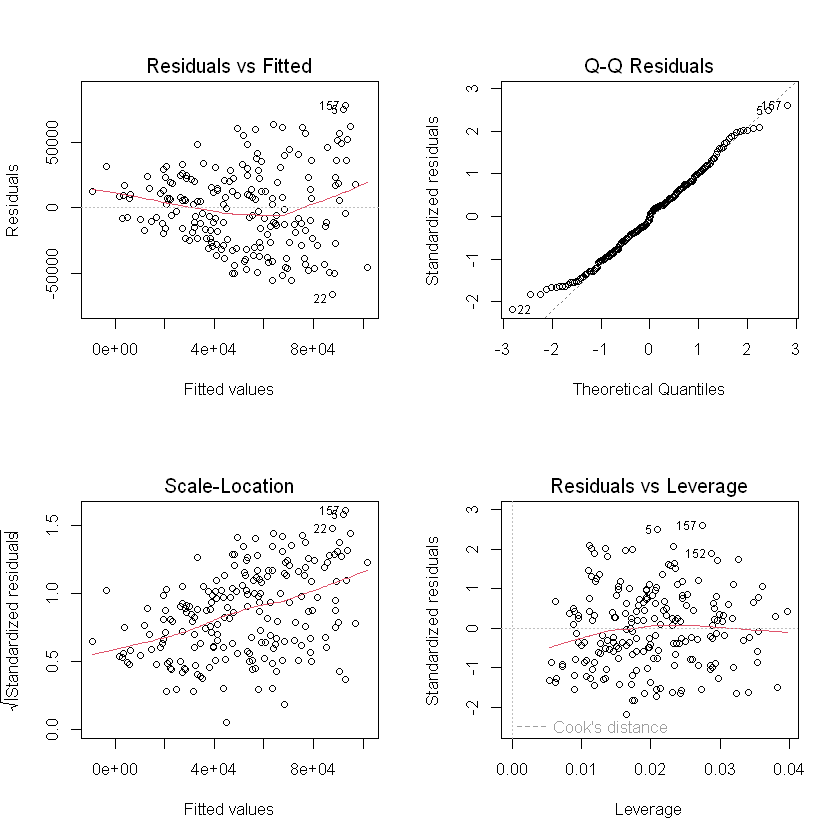

In [18]:
library(car) # for VIF

# 1. Simple Linear Regression
model_simple <- lm(profit_margin ~ units_sold, data = retail_sales)
print("--- Simple Regression Summary ---")
summary(model_simple)

# 2. Multiple Linear Regression
model_multiple <- lm(profit_margin ~ units_sold + discount + ad_spend, data = retail_sales)
print("--- Multiple Regression Summary ---")
summary(model_multiple)

# 3. Multicollinearity Diagnostics (VIF)
print("--- Variance Inflation Factor (VIF) ---")
vif(model_multiple)

# 4. Residual Analysis Plots (This will appear in your 'Plots' pane in RStudio)
par(mfrow=c(2,2)) # Set up a 2x2 grid for plots
plot(model_multiple)
par(mfrow=c(1,1)) # Reset plot window

# Question 4

In [ ]:
install.packages("DescTools")

In [21]:
library(car)
library(DescTools)

# 1. Load the customer loyalty dataset
customer_loyalty <- as.data.frame(read_excel("datasets.xlsx", sheet = "customer_loyalty"))

# 2. Build the binary logistic regression model (forced entry)
loyalty_model <- glm(loyalty_flag ~ frequency_visits + returns + complaint_score, 
                     data = customer_loyalty, family = binomial)

print("--- Logistic Regression Summary ---")
summary(loyalty_model)

# Calculate Odds Ratios
print("--- Odds Ratios ---")
exp(coef(loyalty_model))

# 3. Model Strength and Null Model Comparison
# Fit a null model (intercept only)
null_model <- glm(loyalty_flag ~ 1, data = customer_loyalty, family = binomial)

print("--- Chi-Square Test (Model vs Null) ---")
anova(null_model, loyalty_model, test = "Chisq")

print("--- Pseudo R-Squared Metrics ---")
PseudoR2(loyalty_model, which = c("CoxSnell", "Nagelkerke"))

# 4. Multicollinearity Diagnostics
print("--- VIF for Logistic Model ---")
vif(loyalty_model)


Attaching package: 'DescTools'


The following object is masked from 'package:car':

    Recode




[1] "--- Logistic Regression Summary ---"



Call:
glm(formula = loyalty_flag ~ frequency_visits + returns + complaint_score, 
    family = binomial, data = customer_loyalty)

Coefficients:
                 Estimate Std. Error z value Pr(>|z|)    
(Intercept)       -5.7489     1.7208  -3.341 0.000835 ***
frequency_visits   0.7732     0.1857   4.163 3.14e-05 ***
returns            0.1453     0.2478   0.586 0.557594    
complaint_score   -2.5688     0.5938  -4.326 1.52e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 179.742  on 149  degrees of freedom
Residual deviance:  50.892  on 146  degrees of freedom
AIC: 58.892

Number of Fisher Scoring iterations: 8


[1] "--- Odds Ratios ---"


(Intercept) frequency_visits          returns  complaint_score 
     0.003186153      2.166622596      1.156406217      0.076631012

...

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,149,179.74201,NA,NA,NA
2,146,50.89233,3,128.8497,9.571111e-28


[1] "--- Pseudo R-Squared Metrics ---"


CoxSnell Nagelkerke 
 0.5764136  0.8254677

[1] "--- VIF for Logistic Model ---"


frequency_visits          returns  complaint_score 
        3.913624         1.026595         3.904396

# Question 5

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: 'forecast'


The following object is masked from 'package:DescTools':

    BoxCox



Attaching package: 'MLmetrics'


The following objects are masked from 'package:DescTools':

    AUC, Gini, MAE, MAPE, MSE, RMSE


The following object is masked from 'package:base':

    Recall




[1] "--- P003 Forecasts for Next 2 Months ---"
SMA (k=3): 146.3333 , 146.3333 
SMA (k=6): 130 , 130 
SES (alpha=0.3): 130.5981 , 130.5981 
SES (alpha=0.8): 127.0244 , 127.0244 

[1] "--- Accuracy Metrics (Last 6 Months) ---"
SMA k=3   -> MAD: 35.61111 | MAPE: 30.19043 %
SMA k=6   -> MAD: 29.77778 | MAPE: 24.06725 %
SES a=0.3 -> MAD: 40.54598 | MAPE: 33.25311 %
SES a=0.8 -> MAD: 44.46804 | MAPE: 38.30295 %

[1] "--- P001 Holt-Winters Forecast (Next 2 Months) ---"
       Jan      Feb
3 143.8335 113.6972


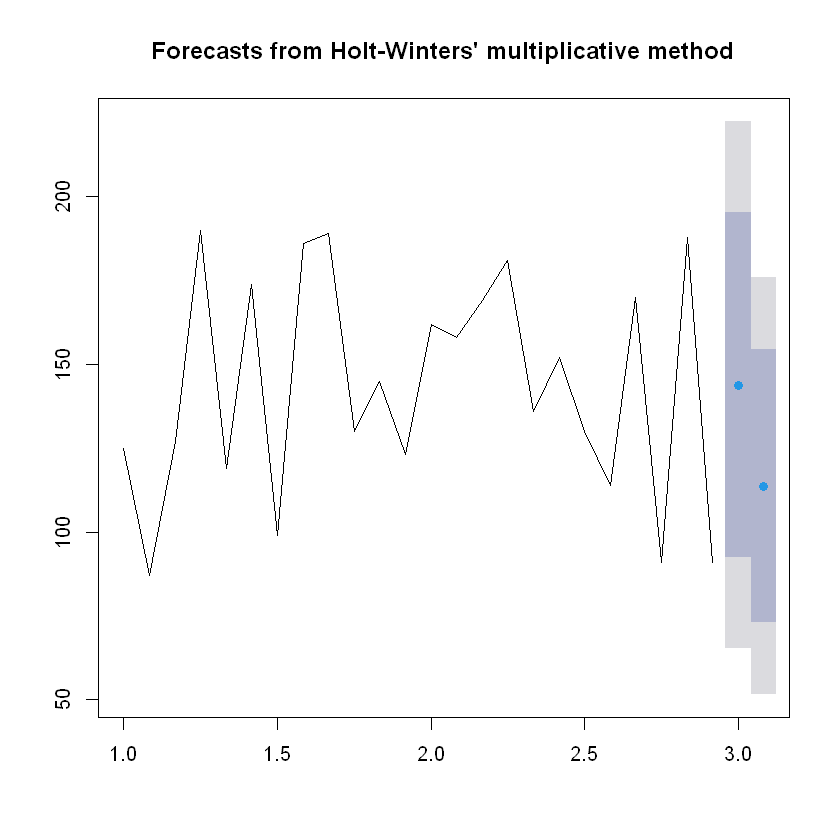

In [22]:
# install.packages("forecast")
# install.packages("MLmetrics")
library(forecast)
library(dplyr)
library(MLmetrics)

# 1. Load the data 
demand_data <- as.data.frame(read_excel("datasets.xlsx", sheet = "forecast_demand"))

# 2. Filter data for P003 and create a time series object
# Assuming monthly data over 2 years (24 months)
p003_data <- demand_data %>% filter(product_id == "P003") %>% arrange(month)
ts_p003 <- ts(p003_data$units_sold, frequency = 12)

# ---- Part A & B: SMA and SES for P003 ----

# SMA k=3 and k=6
sma3 <- ma(ts_p003, order = 3, centre = FALSE)
sma6 <- ma(ts_p003, order = 6, centre = FALSE)

# SES alpha=0.3 and alpha=0.8
ses_03 <- ses(ts_p003, alpha = 0.3, h = 2)
ses_08 <- ses(ts_p003, alpha = 0.8, h = 2)

# Calculate naive forecasts for the next 2 months for SMA
# (Since SMA just averages past periods, the forecast for next period is the last calculated SMA)
last_sma3 <- mean(tail(ts_p003, 3))
last_sma6 <- mean(tail(ts_p003, 6))

print("--- P003 Forecasts for Next 2 Months ---")
cat("SMA (k=3):", last_sma3, ",", last_sma3, "\n")
cat("SMA (k=6):", last_sma6, ",", last_sma6, "\n")
cat("SES (alpha=0.3):", ses_03$mean[1], ",", ses_03$mean[2], "\n")
cat("SES (alpha=0.8):", ses_08$mean[1], ",", ses_08$mean[2], "\n\n")

# Calculate MAD and MAPE over the last 6 months (Months 19 to 24)
actual_last_6 <- tail(ts_p003, 6)
sma3_last_6 <- tail(sma3[!is.na(sma3)], 6)
sma6_last_6 <- tail(sma6[!is.na(sma6)], 6)
ses03_last_6 <- tail(ses_03$fitted, 6)
ses08_last_6 <- tail(ses_08$fitted, 6)

print("--- Accuracy Metrics (Last 6 Months) ---")
cat("SMA k=3   -> MAD:", MAE(sma3_last_6, actual_last_6), "| MAPE:", MAPE(sma3_last_6, actual_last_6)*100, "%\n")
cat("SMA k=6   -> MAD:", MAE(sma6_last_6, actual_last_6), "| MAPE:", MAPE(sma6_last_6, actual_last_6)*100, "%\n")
cat("SES a=0.3 -> MAD:", MAE(ses03_last_6, actual_last_6), "| MAPE:", MAPE(ses03_last_6, actual_last_6)*100, "%\n")
cat("SES a=0.8 -> MAD:", MAE(ses08_last_6, actual_last_6), "| MAPE:", MAPE(ses08_last_6, actual_last_6)*100, "%\n\n")


# ---- Part C: Holt-Winters for P001 ----
p001_data <- demand_data %>% filter(product_id == "P001") %>% arrange(month)
# We assume the data starts at Jan (frequency=12)
ts_p001 <- ts(p001_data$units_sold, frequency = 12)

# Holt-Winters Multiplicative Smoothing
hw_model <- hw(ts_p001, seasonal = "multiplicative", h = 2)

print("--- P001 Holt-Winters Forecast (Next 2 Months) ---")
print(hw_model$mean)

# Plotting the seasonal pattern (Saves to your plot window)
plot(hw_model)

# Question 6

In [24]:
install.packages("lpSolve")
library(lpSolve)

# 1. Load the data
staff_data <- as.data.frame(read_excel("datasets.xlsx", sheet = "staff_allocation")) # Select datasets.xlsx - staff_allocation.csv

# 2. Calculate the specific parameters for each store
staff_data <- staff_data %>%
  mutate(
    # The floor function rounds down to the nearest integer
    min_blocks = floor(required_hours / 150),
    max_blocks = floor(available_hours / 150),
    cost_per_block = wage_rate * 150
  )

num_stores <- nrow(staff_data)
total_required_hours <- sum(staff_data$required_hours)

# 3. Set up the Integer Programming Model

# Objective Function: Minimize Total Cost (cost per block for each store)
objective_coeffs <- staff_data$cost_per_block

# Constraint 1: Total hours allocated >= Total required hours
# Each block is 150 hours. So, 150 * sum(blocks) >= total_required_hours
const_total_hours <- rep(150, num_stores)

# Constraint Matrix:
# We need to build a matrix where the first row is for the total hours constraint,
# followed by rows for the minimum blocks per store, 
# and rows for the maximum blocks per store.
const_mat <- matrix(0, nrow = 1 + 2 * num_stores, ncol = num_stores)

# Row 1: Total hours constraint
const_mat[1, ] <- 150

# Rows for Min Blocks and Max Blocks constraints
for(i in 1:num_stores) {
  const_mat[1 + i, i] <- 1               # Min constraint for store i
  const_mat[1 + num_stores + i, i] <- 1  # Max constraint for store i
}

# Constraint Directions
const_dir <- c(">=", rep(">=", num_stores), rep("<=", num_stores))

# Constraint Right-Hand Sides (RHS)
const_rhs <- c(total_required_hours, staff_data$min_blocks, staff_data$max_blocks)

# 4. Solve the Integer Programming Model
# We set all.int = TRUE because we can only allocate whole integer blocks
solution <- lp(direction = "min", 
               objective.in = objective_coeffs, 
               const.mat = const_mat, 
               const.dir = const_dir, 
               const.rhs = const_rhs, 
               all.int = TRUE)

# 5. Extract and print the results
staff_data$blocks_allocated <- solution$solution
staff_data$hours_allocated <- staff_data$blocks_allocated * 150
total_hours_allocated <- sum(staff_data$hours_allocated)
total_cost <- solution$objval

print("--- Optimal Staffing Allocation per Store ---")
print(staff_data %>% select(store_id, min_blocks, max_blocks, blocks_allocated, hours_allocated))

print("--- Summary Totals ---")
cat("Total Required Hours (Minimum needed overall):", total_required_hours, "\n")
cat("Total Hours Allocated:", total_hours_allocated, "\n")
cat("Final Total Staffing Cost: $", total_cost, "\n")

Installing package into 'C:/Users/Yahya/AppData/Local/R/win-library/4.4'
(as 'lib' is unspecified)



package 'lpSolve' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Yahya\AppData\Local\Temp\RtmpwLfiOR\downloaded_packages
[1] "--- Optimal Staffing Allocation per Store ---"
   store_id min_blocks max_blocks blocks_allocated hours_allocated
1      S001          1          2                2             300
2      S002          1          3                2             300
3      S003          1          2                2             300
4      S004          2          2                2             300
5      S005          2          3                3             450
6      S006          2          2                2             300
7      S007          2          2                2             300
8      S008          1          2                2             300
9      S009          2          2                2             300
10     S010          1          2                2             300
[1] "--- Summary Totals ---"
Total Required H

# Quesiton 7

In [ ]:
install.packages("rpart")
install.packages("rpart.plot")
library(rpart)
library(rpart.plot)

In [33]:
loan_data <- as.data.frame(read_excel("datasets.xlsx", sheet = "loan_tree"))
colnames(loan_data) <- trimws(colnames(loan_data))

In [32]:
colnames(loan_data)

[1] "customer_id"   "income"        "job_type"      "risk_score"   
[5] "loan_approved"

[1] "--- Decision Tree Variable Importance ---"
risk_score     income 
  47.35485   30.48697 
[1] "--- Simulation Results (150 Scenarios) ---"
Baseline Income: 60790.5 
Baseline Risk Score: 0.63 
Overall Approval Rate in Simulation: 100 %



  0   1 
  0 150 

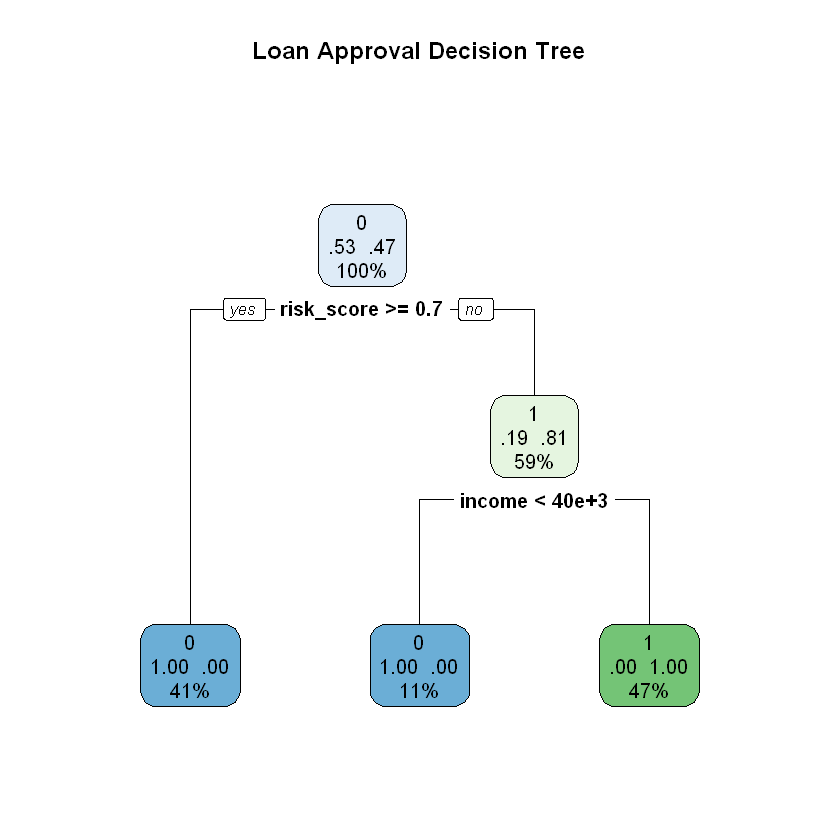

In [34]:
# Build the Decision Tree (Using only income and risk_score)
tree_model <- rpart(loan_approved ~ income + risk_score, 
                    data = loan_data, 
                    method = "class", 
                    control = rpart.control(cp = 0.01))

print("--- Decision Tree Variable Importance ---")
print(tree_model$variable.importance)

# Plot the tree (This will appear in your 'Plots' pane. Right-click and save it!)
rpart.plot(tree_model, main="Loan Approval Decision Tree", extra=104, type=2, fallen.leaves=TRUE)

# Simulate 150 scenarios (Varying Income +/- 15% and Risk +/- 10%)
set.seed(123) # For reproducibility
base_income <- median(loan_data$income, na.rm = TRUE)
base_risk <- median(loan_data$risk_score, na.rm = TRUE)

sim_data <- data.frame(
  income = base_income * runif(150, min = 0.85, max = 1.15),
  risk_score = base_risk * runif(150, min = 0.90, max = 1.10)
)

# Predict approvals for these 150 simulated scenarios
sim_data$predicted_approval <- predict(tree_model, sim_data, type = "class")

# Calculate approval rate for the simulation
approval_rate <- sum(sim_data$predicted_approval == "1") / 150 * 100

print("--- Simulation Results (150 Scenarios) ---")
cat("Baseline Income:", base_income, "\n")
cat("Baseline Risk Score:", base_risk, "\n")
cat("Overall Approval Rate in Simulation:", approval_rate, "%\n")

# Show how approvals break down
table(sim_data$predicted_approval)